# Map DTM Data onto a GPS Track

This notebook illustrates how to use an **Analytical Feature Map (AFMap)** to enrich trajectories. The aggregated value associated with each raster cell is assigned to the observations falling within that cell, allowing spatial information to be propagated back to the original tracks as an **Analytical Feature (AF)**.

In this example, we transfer elevation values from a **Digital Terrain Model (DTM)** to a GPS track. Since the track already contains altitude measurements, the mapped DTM elevations can be compared with the original GPS altitudes at the end of this notebook.


## Importing Tracklib

In [1]:
import os
import numpy as np

# Import the Tracklib library
import tracklib as tkl

# Import plotting library
import matplotlib.pyplot as plt

Code running in a no shapely environment


## Load the GNSS Track

The GNSS track represents a section of a route recorded in the Vercors Regional Natural Park.

Text(901895.5667177888, 6435537.8661504565, 'E')

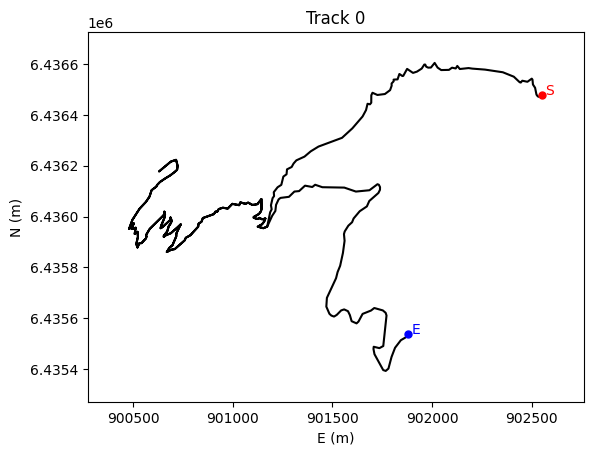

In [2]:
tkl.ObsTime.setReadFormat("4Y-2M-2D 2h:2m:2s")
resource_path = './'
filepath = os.path.join(resource_path, '../../../data/XYZBRAVOSANSFIDOUTEST.txt')
param = tkl.TrackFormat({'ext': 'CSV', 'id_E': 0, 'id_N': 1, 'id_U': 2, 'id_T': -1, 'header':1})
track = tkl.TrackReader.readFromFile(filepath, param)
track = track[400:900]

# Display the track
track.plot()

# Display start and end of route
plt.plot(track[0].position.getX(), track[0].position.getY(), 'ro', markersize=5)
plt.text(track[0].position.getX() + 15, track[0].position.getY() + 1.1, 'S', color="red")

plt.plot(track[499].position.getX(), track[499].position.getY(), 'bo', markersize=5)
plt.text(track[499].position.getX() + 15, track[499].position.getY() + 1.1, 'E', color="blue")

## Load a DTM Tile

-------------------------------------
Raster:                              
-------------------------------------
       nrows = 303
       ncols = 320
       XPixelSize = 5
       YPixelSize = 5
       No data value = -99999.0
       Extent: width = 1600.0, height = 1515.0
   Bounding box: 
       Lower left corner : 900372.5, 6435217.5
       Upper right corner: 901972.5, 6436732.5
-------------------------------------

-------------------------------------
Grid :
-------------------------------------
    Minimum value:  -99999.0
    Maximum value:  2033.31
    Mean value:     544.37695
    Median value:   1515.2
-------------------------------------



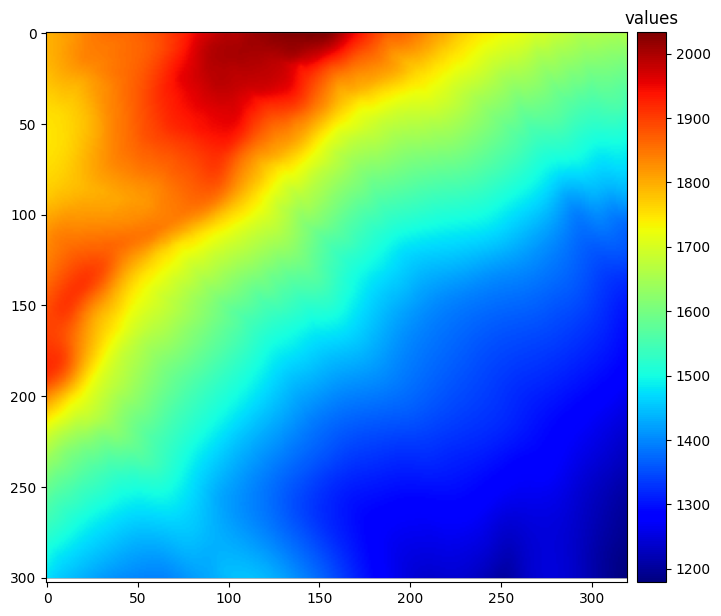

In [3]:
ascfilepath = os.path.join(resource_path, '../../../data/asc/mnt_XYZBRAVOSANSFIDOUTEST_2.asc')
raster = tkl.RasterReader.readFromAscFile(ascfilepath, af_name='MNT', separator=" ")

print (raster)

mnt = raster.getAFMap('MNT')

mnt.histogram('values')
mnt.plot(cmap='jet')

## Map on track and compare with the raw data

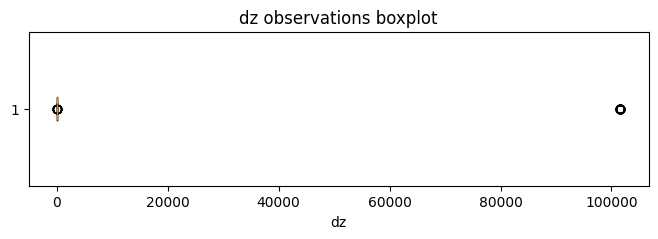

In [4]:
tkl.mapOnRaster(track, raster)

track.operate(tkl.Operator.SUBSTRACTER, "z", "MNT", "diff")
track.operate(tkl.Operator.RECTIFIER, "diff", "dz")

track.plotAnalyticalFeature('dz', 'BOXPLOT')

## Final result graphic

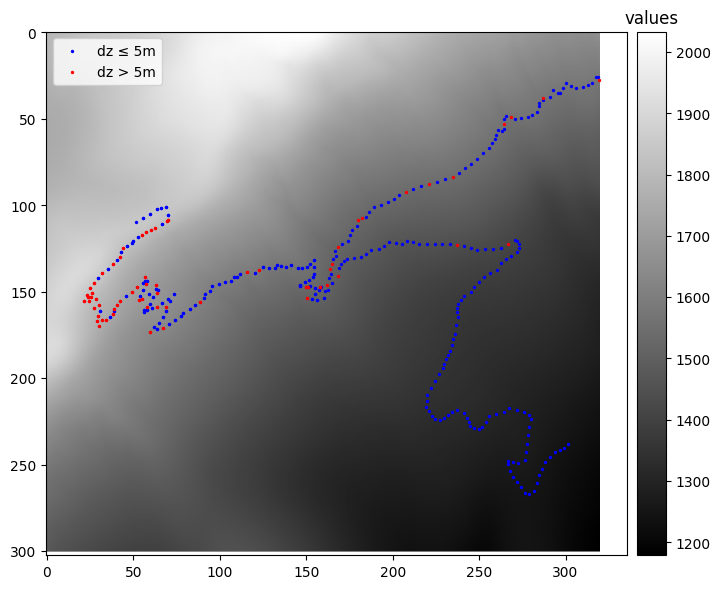

In [5]:
fig, ax1 = plt.subplots(figsize=(8, 8))

# Draw raster
mnt.plot('values', cmap='gist_gray', append=ax1)

X1 = []
X2 = []
Y1 = []
Y2 = []
for i in range(track.size()):
    if raster.isIn(track[i].position):
        idx = (float(track[i].position.getX()) - raster.xmin) / raster.resolution[0]
        idy = (raster.nrow-1) - (float(track[i].position.getY()) - raster.ymin) / raster.resolution[1]
        if track.getObsAnalyticalFeature('dz', i) > 5:
            X2.append(idx)
            Y2.append(idy)
        else:
            X1.append(idx)
            Y1.append(idy)

ax1.scatter(X1, Y1, c='blue', s=2, label='dz ≤ 5m')
ax1.scatter(X2, Y2, c='red', s=2, label='dz > 5m')
ax1.legend()